In [26]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sps

import pyGameWorld as pgw
from pyGameWorld.simulate import simulate_noisypaths, simulate_noisypaths_parallel

In [2]:
sns.set_theme(style="white", rc={"axes.spines.right": False, "axes.spines.top": False})

In [3]:
predictions = pd.read_csv("predictions.csv")

In [4]:
memory = pd.read_csv("memory.csv")
memory["correct_conf"] = memory.apply(lambda x: 100 - x.response if x.answer == 0 else x.response, axis=1)
memory["obj_cond"] = pd.Categorical(memory.obj_cond, categories=["col_early", "col_late", "maybecol", "nocol"], ordered=True)
memory["correct_conf_z"] = memory.groupby("pid")["correct_conf"].transform(lambda x: (x - x.mean()) / x.std())

In [5]:
def throwaway():
    with open("../../experiments/exp_background/assets/targets.json") as f:
        stimuli = json.load(f)

    baseline_points = 0
    for world in memory.world.unique():
        answer = stimuli[world]["col_early"]["foreground"]["sim_x_result"]
        random_clicks = np.random.randint(0, 600, 10)
        baseline_points += (10 - np.abs(np.round(random_clicks / 60) -
                                  np.round(answer / 60))).sum()
    return baseline_points / 16

baseline_points = sum(throwaway() for _ in range(50)) / 50

<Axes: xlabel='points', ylabel='Count'>

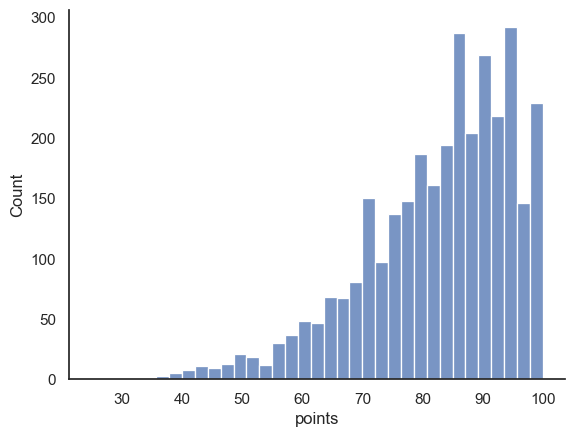

In [6]:
sns.histplot(predictions.points)

In [7]:
avg_predictions = predictions.groupby("pid")["points"].mean().reset_index()

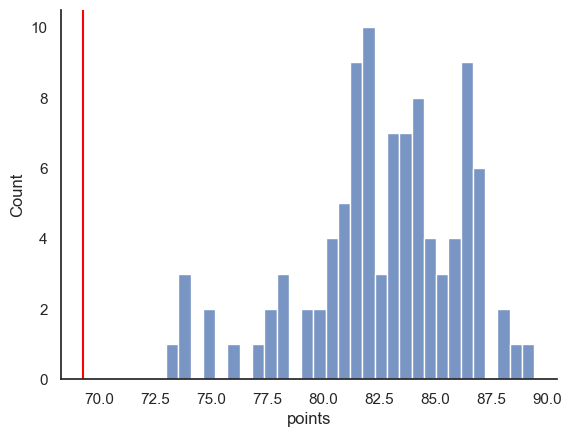

In [8]:
sns.histplot(avg_predictions.points, bins=30)
plt.axvline(x=baseline_points, color="red")

In [9]:
np.quantile(avg_predictions.points, .05)

74.7765625

In [10]:
bad_pids = avg_predictions.loc[avg_predictions.points < 75, "pid"].tolist()

In [11]:
memory = memory.loc[~memory.pid.isin(bad_pids)].reset_index()

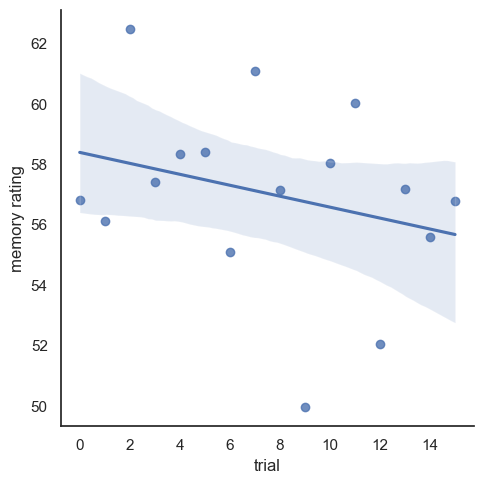

In [12]:
memory.groupby(["trial"])["correct_conf"].mean().reset_index().pipe(
    sns.lmplot, x="trial", y="correct_conf"
).set(ylabel="memory rating")

In [13]:
memory[["trial", "correct_conf"]].corr()

,trial,correct_conf
trial,1.000000,-0.031026
correct_conf,-0.031026,1.000000


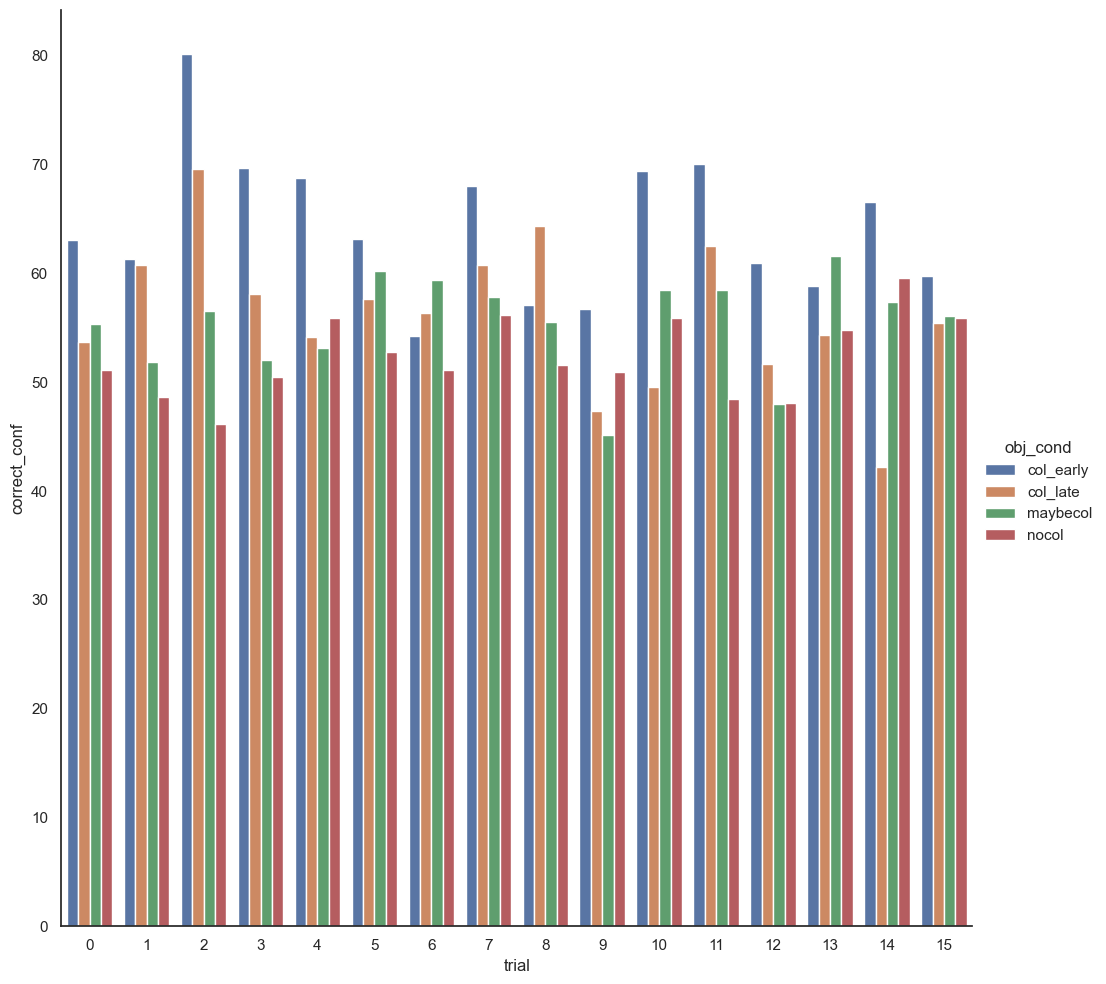

In [14]:
memory.groupby(["trial", "obj_cond"])["correct_conf"].mean().reset_index().pipe(
    sns.catplot, x="trial", y="correct_conf", hue="obj_cond", kind="bar", height=10
)

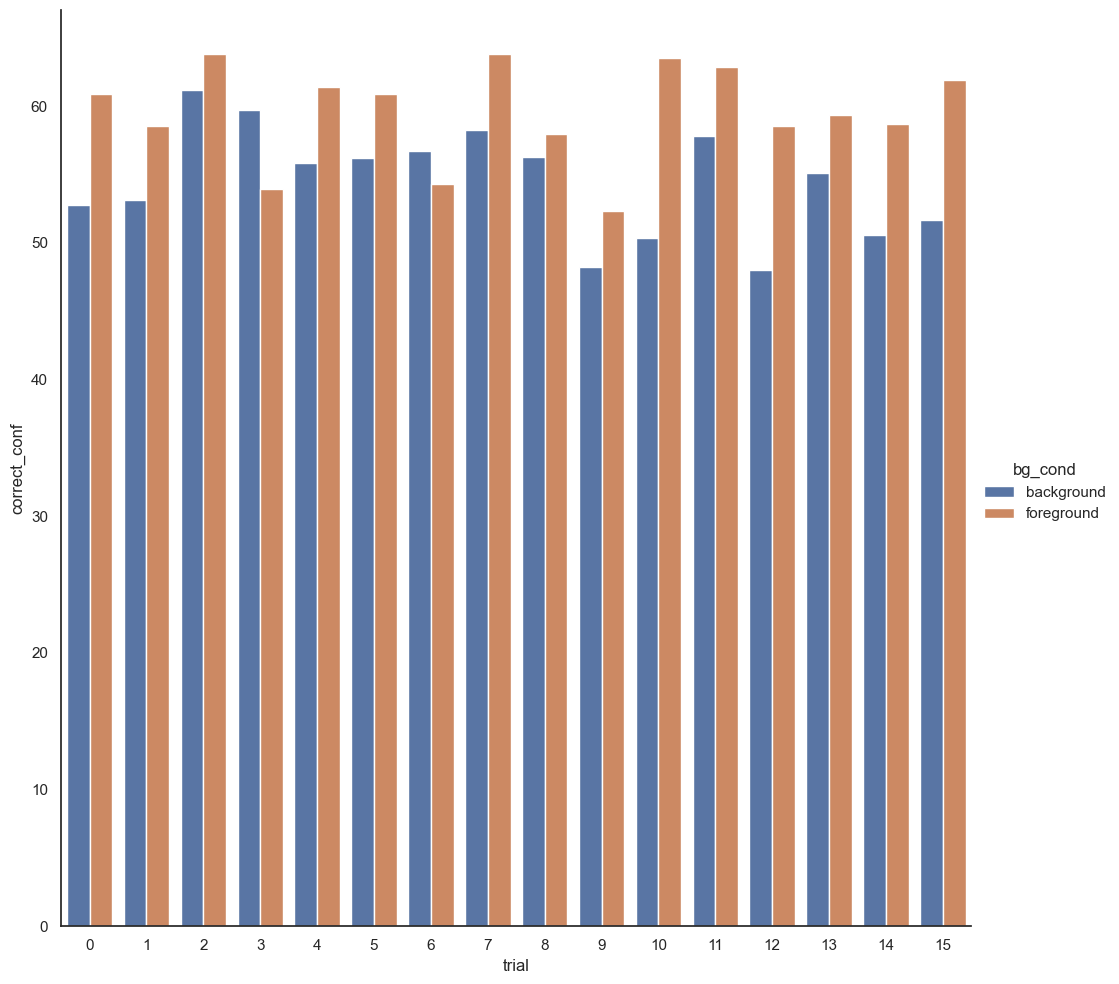

In [15]:
memory.groupby(["trial", "bg_cond"])["correct_conf"].mean().reset_index().pipe(
    sns.catplot, x="trial", y="correct_conf", hue="bg_cond", kind="bar", height=10
)

[Text(0.5, 0, '')]

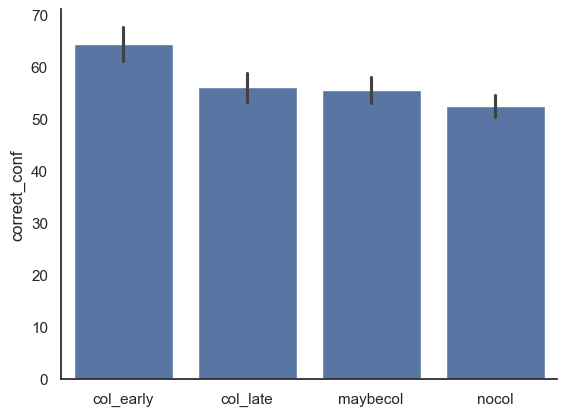

In [16]:
sns.barplot(memory, x="obj_cond", y="correct_conf").set(xlabel="")

In [17]:
memory.groupby("obj_cond")["correct_conf"].mean()

obj_cond
col_early    64.263298
col_late     56.047872
maybecol     55.414894
nocol        52.436170
Name: correct_conf, dtype: float64

[Text(0.5, 0, '')]

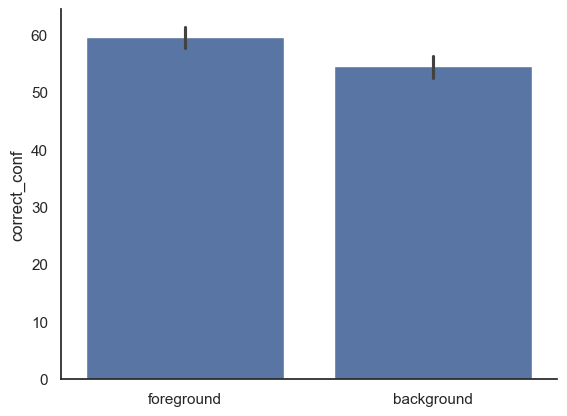

In [18]:
sns.barplot(memory, x="bg_cond", y="correct_conf").set(xlabel="")

In [19]:
memory.groupby("bg_cond")["correct_conf"].mean()

bg_cond
background    54.506649
foreground    59.574468
Name: correct_conf, dtype: float64

[Text(0.5, 0, '')]

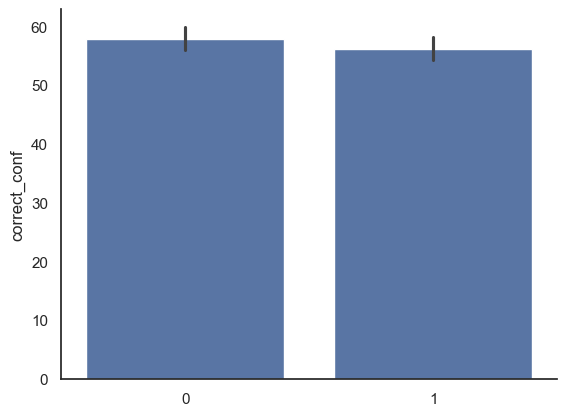

In [20]:
sns.barplot(memory, x="background_color_idx", y="correct_conf").set(xlabel="")

In [21]:
memory.columns

Index(['index', 'trial', 'rt', 'response', 'baseimg0', 'baseimg1',
       'recording0', 'recording1', 'obj_name', 'worldtype', 'sim_x_result',
       'obj_cond', 'bg_cond', 'world', 'cond', 'count', 'img0', 'img1',
       'background_color_idx', 'background_color', 'pid', 'answer', 'img',
       'correct_conf', 'correct_conf_z'],
      dtype='object')

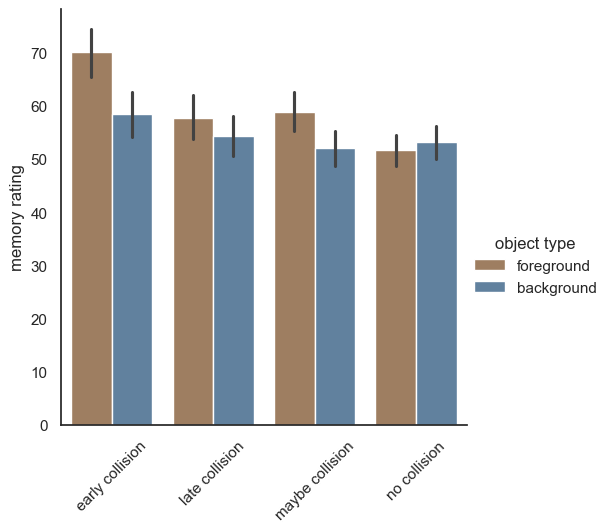

In [22]:
p = sns.catplot(memory, x="obj_cond", y="correct_conf", hue="bg_cond", kind="bar", palette=["#A87E57E6", "#5781A8E6"])
p.set(xlabel="", ylabel="memory rating")
p._legend.set_title("object type")
p.set_xticklabels(["early collision", "late collision", "maybe collision", "no collision"], rotation=45)

# plt.gcf().savefig("../../figures/foreground_background_memory.pdf", bbox_inches="tight")
# plt.legend(title="object type")

/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_96474/2323103158.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  p.set_xticklabels(["early collision", "late collision", "maybe collision", "no collision"], rotation=45)


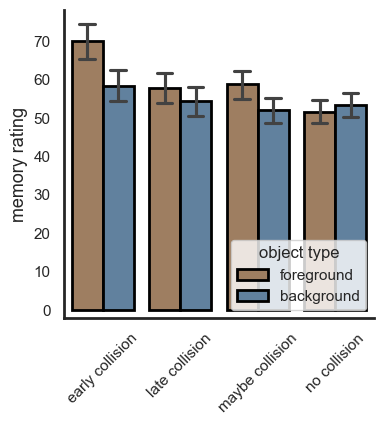

In [23]:
import matplotlib.colors as mcolors
from matplotlib.colors import ColorConverter

colors = ["#A87E57", "#5781A8"]
colors = [mcolors.to_rgba(c, alpha=0.01) for c in colors]

fig, ax = plt.subplots(figsize=(4,4))
p = sns.barplot(memory, x="obj_cond", y="correct_conf", hue="bg_cond", palette=colors, ec="black", lw=2, capsize=0.4)
ax.set_ylim(-2)
ax.set_ylabel("memory rating", fontsize=13)
ax.set_xlabel("")
plt.legend().set(title="object type")
p.set_xticklabels(["early collision", "late collision", "maybe collision", "no collision"], rotation=45)
for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

# plt.gcf().savefig("../../figures/foreground_background_memory.pdf", bbox_inches="tight")

In [24]:
collisions = pd.read_csv("../exp_likelihood/collision_judgments_cleaned.csv")
collisions["cond"] = collisions["cond"].apply(lambda x: x[:-10])
tmp = collisions.groupby(["cond", "world"])[["response", "response_z"]].mean().reset_index()
tmp = tmp.rename({"response": "collision_likelihood", "response_z": "collision_likelihood_z"}, axis=1)
fulldata = pd.merge(memory, tmp, left_on=["world", "obj_cond"], right_on=["world", "cond"])

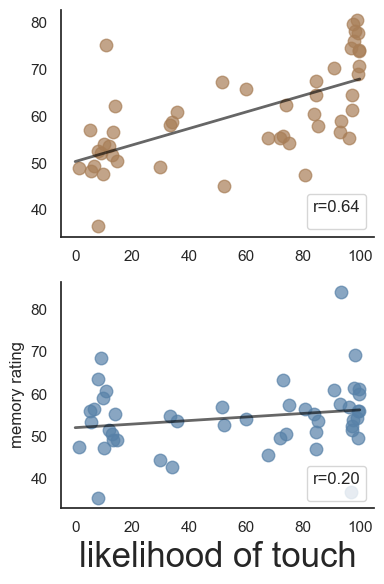

In [25]:
colors = ["#A87E57", "#5781A8"]

plt.figure(figsize=(4, 6))
plt.subplot(2, 1, 1)
tmp = fulldata[fulldata.bg_cond == "foreground"].groupby(["world", "obj_cond"])[["collision_likelihood", "correct_conf"]].mean().reset_index()
plt.plot("collision_likelihood", "correct_conf", "o", data=tmp, color=colors[0],
            markersize=9, alpha=0.7)
b, a, *_ = sps.linregress(tmp.collision_likelihood, y=tmp.correct_conf)
plt.plot([0, 100], [a, a + 100 * b], "-", lw=2, c="black", alpha=0.6)
plt.legend([], loc="lower right", title=f"r={tmp.collision_likelihood.corr(tmp.correct_conf):.2f}")

plt.subplot(2, 1, 2)
tmp = fulldata[fulldata.bg_cond == "background"].groupby(["world", "obj_cond"])[["collision_likelihood", "correct_conf"]].mean().reset_index()
plt.plot("collision_likelihood", "correct_conf", "o", data=tmp, color=colors[1],
            markersize=9, alpha=0.7)
b, a, *_ = sps.linregress(tmp.collision_likelihood, y=tmp.correct_conf)
plt.plot([0, 100], [a, a + 100 * b], "-", lw=2, c="black", alpha=0.6)
plt.legend([], loc="lower right", title=f"r={tmp.collision_likelihood.corr(tmp.correct_conf):.2f}")

plt.xlabel("likelihood of touch", fontsize=25)
plt.ylabel("memory rating")
plt.legend([], loc="lower right", title=f"r={tmp.collision_likelihood.corr(tmp.correct_conf):.2f}")
plt.tight_layout()

# plt.gcf().savefig("../../figures/human_memory_collision_fgbg.pdf")

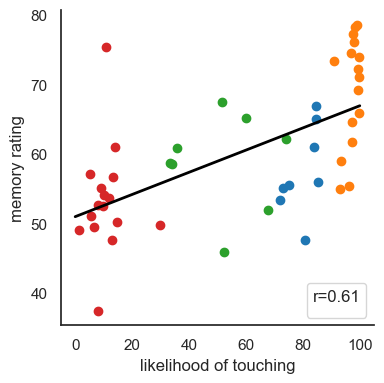

In [27]:
fig, ax = plt.subplots(figsize=(4, 4))
tmp = fulldata[fulldata.bg_cond == "foreground"].groupby(["world", "obj_cond"])[["collision_likelihood", "correct_conf"]].mean().reset_index()
plt.scatter(x="collision_likelihood", y="correct_conf", data=tmp.loc[tmp.obj_cond == "col_early"], color="tab:orange", label="early collision")
plt.scatter(x="collision_likelihood", y="correct_conf", data=tmp.loc[tmp.obj_cond == "maybecol"], color="tab:green", label="maybe collision")
plt.scatter(x="collision_likelihood", y="correct_conf", data=tmp.loc[tmp.obj_cond == "col_late"], color="tab:blue", label="late collision")
plt.scatter(x="collision_likelihood", y="correct_conf", data=tmp.loc[tmp.obj_cond == "nocol"], color="tab:red", label="no collision")

b, a, *_ = sps.linregress(tmp.collision_likelihood, y=tmp.correct_conf)
plt.plot([0, 100], [a, a + 100 * b], "-", lw=2, c="black")

plt.xlabel("likelihood of touching")
plt.ylabel("memory rating")
plt.legend([], loc="lower right", title=f"r={tmp.collision_likelihood.corr(tmp.correct_conf):.2f}")
plt.tight_layout()

plt.gcf().savefig("../../figures/human_memory_collision_fg.pdf")

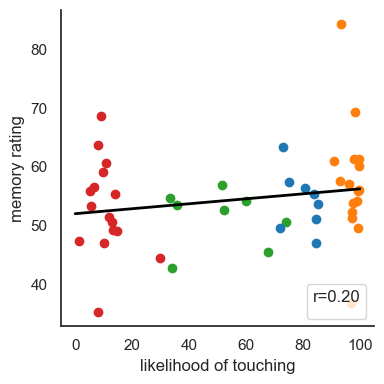

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
tmp = fulldata[fulldata.bg_cond == "background"].groupby(["world", "obj_cond"])[["collision_likelihood", "correct_conf"]].mean().reset_index()
plt.scatter(x="collision_likelihood", y="correct_conf", data=tmp.loc[tmp.obj_cond == "col_early"], color="tab:orange", label="early collision")
plt.scatter(x="collision_likelihood", y="correct_conf", data=tmp.loc[tmp.obj_cond == "maybecol"], color="tab:green", label="maybe collision")
plt.scatter(x="collision_likelihood", y="correct_conf", data=tmp.loc[tmp.obj_cond == "col_late"], color="tab:blue", label="late collision")
plt.scatter(x="collision_likelihood", y="correct_conf", data=tmp.loc[tmp.obj_cond == "nocol"], color="tab:red", label="no collision")

b, a, *_ = sps.linregress(tmp.collision_likelihood, y=tmp.correct_conf)
plt.plot([0, 100], [a, a + 100 * b], "-", lw=2, c="black")

plt.xlabel("likelihood of touching")
plt.ylabel("memory rating")
plt.legend([], loc="lower right", title=f"r={fulldata.loc[fulldata.bg_cond == 'background'].groupby(['world', 'obj_cond'])[['collision_likelihood', 'correct_conf']].mean().corr().iloc[0, 1]:.2f}")
plt.tight_layout()

plt.gcf().savefig("../../figures/human_memory_collision_bg.pdf")

In [19]:
def batch_predict(worlds, pars):
    out = {}
    for wname, world in worlds.items():
        out[wname] = predict(world, **pars)
    # breakpoint()
    return out


def predict(world, **pars):
    paths = simulate_noisypaths_parallel(world, stepsize=0.5, N=100, **pars)
    # breakpoint()
    obj_freq = {}
    for name, obj in world.objects.items():
        if "bump" not in name:
            continue
        obj_freq[name] = 0
        for p in paths:
            for col in p["collisions"]:
                if name in col:
                    obj_freq[name] += 1 / len(paths)
                    break

    for name, val in obj_freq.items():
        obj_freq[name] = np.clip(val, 0.05, 1)

    # breakpoint()
    return obj_freq

In [20]:
worlds = {
    w: pgw.loadFromDict(
        json.load(open(f"../../experiments/assets/exp_likelihood/targets/{w}/{w}.json"))["world"]
    )
    for w in fulldata.world.unique()
}
pars = [0.6, 0.6, 0.2]
# pars = [0.7, 0.5, 0.2]

pars = {
    "noise_position_static": 0.0,
    "noise_position_moving": 5.0,
    "noise_collision_direction": pars[0],
    "noise_collision_elasticity": pars[1],
    "noise_gravity": pars[2],
}

model_predictions = pd.DataFrame(batch_predict(worlds, pars))
model_predictions = model_predictions.assign(object = model_predictions.index).reset_index(drop=True)
model_predictions = pd.melt(model_predictions, id_vars = ["object"], var_name="world", value_name="model_p")
model_predictions = model_predictions.loc[~model_predictions.model_p.isna()]
model_predictions["obj_name"] = model_predictions.object

model_predictions = pd.merge(fulldata[["collision_likelihood", "bg_cond", "obj_cond", "world", "obj_name", "correct_conf"]], model_predictions, on=["world", "obj_name"], how="left")
print(model_predictions[["model_p", "collision_likelihood"]].corr())


                       model_p  collision_likelihood
model_p               1.000000              0.900239
collision_likelihood  0.900239              1.000000


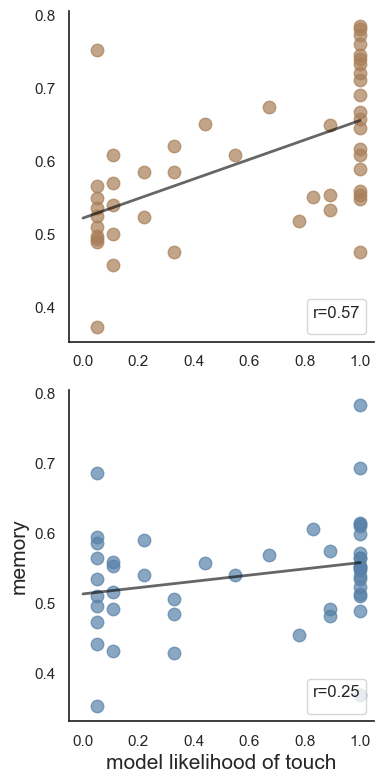

In [67]:
colors = ["#A87E57", "#5781A8"]

plt.figure(figsize=(4, 8))
plt.subplot(2, 1, 1)
tmp = model_predictions[model_predictions.bg_cond == "foreground"].groupby(["world", "obj_cond"])[["model_p", "correct_conf"]].mean().reset_index()
tmp["correct_conf"] /= 100
plt.plot("model_p", "correct_conf", "o", data=tmp, color=colors[0],
            markersize=9, alpha=0.7)
b, a, *_ = sps.linregress(tmp.model_p, y=tmp.correct_conf)
plt.plot([0, 1], [a, a + 1 * b], "-", lw=2, c="black", alpha=0.6)
plt.legend([], loc="lower right", title=f"r={tmp.model_p.corr(tmp.correct_conf):.2f}")

plt.subplot(2, 1, 2)
tmp = model_predictions[model_predictions.bg_cond == "background"].groupby(["world", "obj_cond"])[["model_p", "correct_conf"]].mean().reset_index()
tmp["correct_conf"] /= 100
plt.plot("model_p", "correct_conf", "o", data=tmp, color=colors[1],
            markersize=9, alpha=0.7)
b, a, *_ = sps.linregress(tmp.model_p, y=tmp.correct_conf)
plt.plot([0, 1], [a, a + 1 * b], "-", lw=2, c="black", alpha=0.6)
plt.legend([], loc="lower right", title=f"r={tmp.model_p.corr(tmp.correct_conf):.2f}")

plt.xlabel("model likelihood of touch", fontsize=15)
plt.ylabel("memory", fontsize=15)
plt.legend([], loc="lower right", title=f"r={tmp.model_p.corr(tmp.correct_conf):.2f}")
plt.tight_layout()

plt.gcf().savefig("../../figures/model_memory_collision_fgbg.pdf")

In [27]:
import sys
import os

sys.path.append(os.path.abspath("../../models"))

In [32]:
from process_model import process_model

worlds = {
    w: pgw.loadFromDict(
        json.load(open(f"../../experiments/assets/exp_likelihood/targets/{w}/{w}.json"))["world"]
    )
    for w in fulldata.world.unique()
}
noisysim_pars = {
    "noise_position_static": 0.0,
    "noise_position_moving": 5.0,
    "noise_collision_direction": 0.6,
    "noise_collision_elasticity": 0.6,
    "noise_gravity": 0.2,
}

def model_predict(worlds, radius=25, n_sims=50):
    out = []
    for wname, world in worlds.items():
        print(wname)
        # out[wname] = process_model(world, radius=radius, n_sims=n_sims)
        obj_probs, _ = process_model(world, radius=radius, n_sims=n_sims, noisysim_pars=noisysim_pars)

        data = {"obj_name": list(obj_probs.keys()), "model_p": list(obj_probs.values())}
        world_predictions = pd.DataFrame(data)
        world_predictions["world"] = wname
        out.append(world_predictions)
    return pd.concat(out)

process_model_predictions = model_predict(worlds, radius=25, n_sims=50)
# process_model_predictions.rename(columns={"obj_name": "object"}, inplace=True)
process_model_predictions = pd.merge(fulldata[["collision_likelihood", "bg_cond", "obj_cond", "world", "obj_name", "correct_conf"]], process_model_predictions, on=["world", "obj_name"], how="left")

lh_hl_unlink_plinko_0036
lh_ll_unlink_plinko_0060
lh_hl_unlink_plinko_0110
hh_hl_unlink_plinko_0105
lh_ll_unlink_plinko_0217
hh_hl_unlink_plinko_0202
hh_hl_unlink_plinko_0315
hh_hl_unlink_plinko_0393
lh_ll_unlink_plinko_0091
lh_ll_unlink_plinko_0155
hh_hl_unlink_plinko_0246
lh_hl_unlink_plinko_0111
lh_hl_unlink_plinko_0049
hh_hl_unlink_plinko_0240
hh_hl_unlink_plinko_0269
hh_hl_unlink_plinko_0252


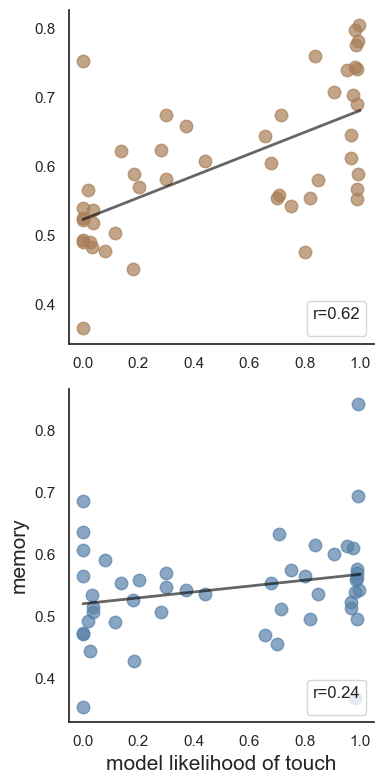

In [34]:
colors = ["#A87E57", "#5781A8"]

plt.figure(figsize=(4, 8))
plt.subplot(2, 1, 1)
tmp = process_model_predictions[process_model_predictions.bg_cond == "foreground"].groupby(["world", "obj_cond"])[["model_p", "correct_conf"]].mean().reset_index()
tmp["correct_conf"] /= 100
plt.plot("model_p", "correct_conf", "o", data=tmp, color=colors[0],
            markersize=9, alpha=0.7)
b, a, *_ = sps.linregress(tmp.model_p, y=tmp.correct_conf)
plt.plot([0, 1], [a, a + 1 * b], "-", lw=2, c="black", alpha=0.6)
plt.legend([], loc="lower right", title=f"r={tmp.model_p.corr(tmp.correct_conf):.2f}")

plt.subplot(2, 1, 2)
tmp = process_model_predictions[process_model_predictions.bg_cond == "background"].groupby(["world", "obj_cond"])[["model_p", "correct_conf"]].mean().reset_index()
tmp["correct_conf"] /= 100
plt.plot("model_p", "correct_conf", "o", data=tmp, color=colors[1],
            markersize=9, alpha=0.7)
b, a, *_ = sps.linregress(tmp.model_p, y=tmp.correct_conf)
plt.plot([0, 1], [a, a + 1 * b], "-", lw=2, c="black", alpha=0.6)
plt.legend([], loc="lower right", title=f"r={tmp.model_p.corr(tmp.correct_conf):.2f}")

plt.xlabel("model likelihood of touch", fontsize=15)
plt.ylabel("memory", fontsize=15)
plt.legend([], loc="lower right", title=f"r={tmp.model_p.corr(tmp.correct_conf):.2f}")
plt.tight_layout()

# plt.gcf().savefig("../../figures/model_memory_collision_fgbg.pdf")

In [34]:
%load_ext rpy2.ipython

In [35]:
%%R -i fulldata
library(lme4)
model = lmer("correct_conf ~ 1 + (1 | pid) + collision_likelihood + bg_cond + collision_likelihood * bg_cond", data=fulldata)
print(summary(model))
basemodel = lmer("correct_conf ~ 1 + (1 | pid) + collision_likelihood + bg_cond", data=fulldata)
print("--- comparing no interaction model vs interaction model")
print(anova(model, basemodel))

Linear mixed model fit by REML ['lmerMod']
Formula: correct_conf ~ 1 + (1 | pid) + collision_likelihood + bg_cond +  
    collision_likelihood * bg_cond
   Data: fulldata

REML criterion at convergence: 13244

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.66868 -0.50927 -0.03052  0.75743  2.00006 

Random effects:
 Groups   Name        Variance Std.Dev.
 pid      (Intercept)  24.63    4.962  
 Residual             681.61   26.108  
Number of obs: 1410, groups:  pid, 94

Fixed effects:
                                       Estimate Std. Error t value
(Intercept)                            52.19061    2.06083  25.325
collision_likelihood                    0.03086    0.02908   1.061
bg_condforeground                      -3.36076    2.79712  -1.202
collision_likelihood:bg_condforeground  0.14955    0.04091   3.655

Correlation of Fixed Effects:
            (Intr) cllsn_ bg_cnd
cllsn_lklhd -0.843              
bg_cndfrgrn -0.692  0.621       
cllsn_lkl:_  0.600 -0.7

Loading required package: Matrix
refitting model(s) with ML (instead of REML)
In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages


In [74]:
for obj in ["col_early", "col_late", "maybecol", "nocol"]:
    print(obj)
    print(sps.ttest_ind(memory.loc[(memory.obj_cond == obj) & (memory.bg_cond == "foreground"), "correct_conf"],
                    memory.loc[(memory.obj_cond == obj) & (memory.bg_cond == "background"), "correct_conf"]))

col_early
Ttest_indResult(statistic=3.656385489370006, pvalue=0.0002924325672925155)
col_late
Ttest_indResult(statistic=1.1896766414990696, pvalue=0.23492819564993747)
maybecol
Ttest_indResult(statistic=2.6613755726814525, pvalue=0.008117683378718826)
nocol
Ttest_indResult(statistic=-0.7603610862519208, pvalue=0.4475178459796779)


In [37]:
sps.ttest_ind(memory.loc[memory.bg_cond == "foreground", "correct_conf"], memory.loc[memory.bg_cond == "background", "correct_conf"])

Ttest_indResult(statistic=3.6617288722567727, pvalue=0.00025920581841124766)

In [38]:
import json

objs_per_world = {"world": [], "objs_in_world": []}
for world in memory.world.unique():
    print(world)
    objs_per_world["world"].append(world)
    with open(f"../../experiments/exp1/assets/targets/{world}/{world}.json") as f:
        j = json.load(f)
    objs_per_world["objs_in_world"].append(
        sum(1 for o in j["world"]["objects"] if "bump" in o)
    )
objs_per_world = pd.DataFrame(objs_per_world)

lh_hl_unlink_plinko_0036
lh_ll_unlink_plinko_0060
lh_hl_unlink_plinko_0110
hh_hl_unlink_plinko_0105
lh_ll_unlink_plinko_0217
hh_hl_unlink_plinko_0202
hh_hl_unlink_plinko_0315
hh_hl_unlink_plinko_0393
lh_ll_unlink_plinko_0091
lh_ll_unlink_plinko_0155
hh_hl_unlink_plinko_0246
lh_hl_unlink_plinko_0111
lh_hl_unlink_plinko_0049
hh_hl_unlink_plinko_0240
hh_hl_unlink_plinko_0269
hh_hl_unlink_plinko_0252


In [39]:
fulldata = pd.merge(fulldata, objs_per_world, on="world")

In [40]:
fulldata

,trial,rt,response,baseimg0,baseimg1,recording0,recording1,obj_name,worldtype,sim_x_result,...,background_color,pid,answer,img,correct_conf,correct_conf_z,cond_y,collision_likelihood,collision_likelihood_z,objs_in_world
0,0,33190,29,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,bottombump_2,definite,276.918239,...,blue,55bc8f61fdf99b064522525c,0,assets/targets/lh_hl_unlink_plinko_0036/col_la...,71,1.841106,col_late,75.125000,0.381972,8
1,12,3284,27,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,bottombump_2,definite,276.918239,...,blue,5ef4f8549a068610f5530b4d,0,assets/targets/lh_hl_unlink_plinko_0036/col_la...,73,0.733016,col_late,75.125000,0.381972,8
2,5,16039,50,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,bottombump_2,definite,276.918239,...,blue,63af5c586c05eee8c3d03730,1,assets/targets/lh_hl_unlink_plinko_0036/col_la...,50,0.287223,col_late,75.125000,0.381972,8
3,6,16518,26,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,bottombump_2,definite,276.918239,...,brown,5617203c5c62cf0005822f0c,0,assets/targets/lh_hl_unlink_plinko_0036/col_la...,74,0.528571,col_late,75.125000,0.381972,8
4,14,3195,50,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,assets/targets/lh_hl_unlink_plinko_0036/col_la...,bottombump_2,definite,116.689551,...,blue,6479c87daabda4a5809a752d,0,assets/targets/lh_hl_unlink_plinko_0036/col_la...,50,-0.261402,col_late,75.125000,0.381972,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405,12,6582,46,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,bottombump_1,maybe,414.137046,...,brown,64abee38a80dfb5e45212487,0,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,54,-0.573557,nocol,9.230769,-1.201698,9
1406,11,4407,50,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,bottombump_1,maybe,414.137046,...,blue,586372cae16d530001b345b8,0,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,50,0.365165,nocol,9.230769,-1.201698,9
1407,14,9561,39,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,bottombump_1,maybe,414.137046,...,brown,5f6fd1451758e95a989623b2,0,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,61,0.300531,nocol,9.230769,-1.201698,9
1408,7,4221,46,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,bottombump_1,maybe,414.137046,...,brown,60e7044ddc2523fab6cbc0cd,0,assets/targets/hh_hl_unlink_plinko_0252/nocol_...,54,-0.133939,nocol,9.230769,-1.201698,9


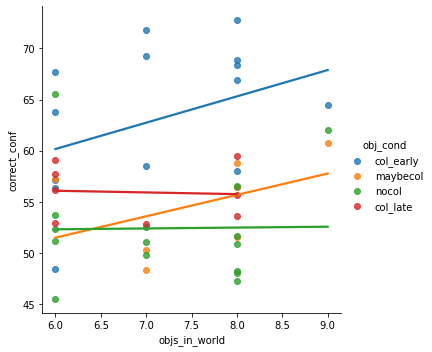

In [41]:
fulldata.groupby(["world", "obj_cond"])[["objs_in_world", "correct_conf"]].mean().reset_index().pipe(
    sns.lmplot, x="objs_in_world", y="correct_conf", hue="obj_cond", ci=None
)

In [42]:
# two weird outliers - nocol for worlds 0202 and 0252
fulldata[(fulldata.obj_cond == "maybecol")].groupby(["world", "bg_cond"])["correct_conf"].mean().sort_values()

world                     bg_cond   
hh_hl_unlink_plinko_0393  background    42.750000
hh_hl_unlink_plinko_0246  foreground    45.148148
hh_hl_unlink_plinko_0269  background    45.500000
hh_hl_unlink_plinko_0246  background    52.600000
hh_hl_unlink_plinko_0202  background    53.500000
hh_hl_unlink_plinko_0315  background    54.172414
hh_hl_unlink_plinko_0105  background    54.680000
hh_hl_unlink_plinko_0269  foreground    55.421053
hh_hl_unlink_plinko_0252  background    56.909091
hh_hl_unlink_plinko_0105  foreground    58.192308
hh_hl_unlink_plinko_0393  foreground    58.875000
hh_hl_unlink_plinko_0202  foreground    60.840000
hh_hl_unlink_plinko_0315  foreground    65.842105
hh_hl_unlink_plinko_0252  foreground    67.421053
Name: correct_conf, dtype: float64

In [43]:
fulldata[(fulldata.obj_cond == "col_early") & (fulldata.bg_cond == "background")].groupby(["world", "bg_cond"])["correct_conf"].mean().sort_values()

world                     bg_cond   
lh_ll_unlink_plinko_0060  background    36.777778
hh_hl_unlink_plinko_0315  background    49.538462
hh_hl_unlink_plinko_0269  background    51.363636
hh_hl_unlink_plinko_0393  background    52.307692
lh_hl_unlink_plinko_0049  background    53.875000
lh_hl_unlink_plinko_0036  background    54.250000
hh_hl_unlink_plinko_0202  background    55.909091
lh_hl_unlink_plinko_0111  background    56.083333
lh_ll_unlink_plinko_0155  background    57.000000
lh_ll_unlink_plinko_0091  background    57.600000
hh_hl_unlink_plinko_0252  background    60.076923
hh_hl_unlink_plinko_0105  background    61.000000
lh_ll_unlink_plinko_0217  background    61.272727
hh_hl_unlink_plinko_0246  background    61.400000
lh_hl_unlink_plinko_0110  background    69.315789
Name: correct_conf, dtype: float64

In [44]:
memory.loc[memory.obj_cond == "nocol"].groupby(["world", "bg_cond"])["correct_conf"].count()

world                     bg_cond   
hh_hl_unlink_plinko_0105  background     6
                          foreground    13
hh_hl_unlink_plinko_0202  background    14
                          foreground     7
hh_hl_unlink_plinko_0240  background    16
                          foreground     7
hh_hl_unlink_plinko_0246  background    15
                          foreground    15
hh_hl_unlink_plinko_0252  background    12
                          foreground     8
hh_hl_unlink_plinko_0269  background    17
                          foreground    14
hh_hl_unlink_plinko_0315  background    10
                          foreground    13
hh_hl_unlink_plinko_0393  background    12
                          foreground    14
lh_hl_unlink_plinko_0036  background    11
                          foreground    13
lh_hl_unlink_plinko_0049  background    12
                          foreground    18
lh_hl_unlink_plinko_0110  background    11
                          foreground    15
lh_hl_unlink_plin

In [45]:
memory.loc[memory.obj_cond == "maybecol"].groupby(["world", "bg_cond"])["correct_conf"].count()

world                     bg_cond   
hh_hl_unlink_plinko_0105  background    25
                          foreground    26
hh_hl_unlink_plinko_0202  background    24
                          foreground    25
hh_hl_unlink_plinko_0240  background    17
                          foreground    29
hh_hl_unlink_plinko_0246  background    20
                          foreground    27
hh_hl_unlink_plinko_0252  background    33
                          foreground    19
hh_hl_unlink_plinko_0269  background    20
                          foreground    19
hh_hl_unlink_plinko_0315  background    29
                          foreground    19
hh_hl_unlink_plinko_0393  background    20
                          foreground    24
Name: correct_conf, dtype: int64

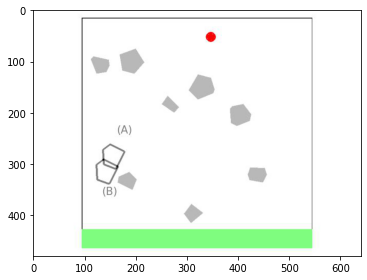

In [46]:
import matplotlib.image as mimg

def viz_memory(world, obj_cond):
    path = f"../../experiments/exp_background/assets/targets/{world}/{obj_cond}_background_memory_1_0.jpg"
    img = mimg.imread(path)
    plt.imshow(img)
    plt.tight_layout()

viz_memory("hh_hl_unlink_plinko_0252", "nocol")

In [ ]:
viz_memory("hh_hl_unlink_plinko_0240", "col_early")

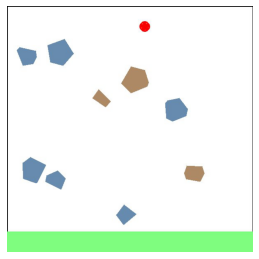

In [50]:
def viz_world(world, obj_cond):
    path = f"../../experiments/exp_background/assets/targets/{world}/{obj_cond}_background_0.jpg"
    img = mimg.imread(path)
    plt.imshow(img)
    plt.tight_layout()
    plt.axis("off")

viz_world("hh_hl_unlink_plinko_0252", "col_early")

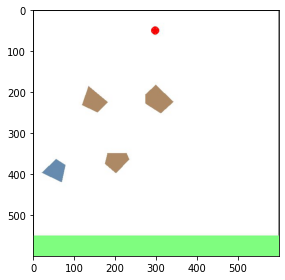

In [49]:
viz_world("hh_hl_unlink_plinko_0240", "col_early")